In [1]:
# -*- coding: utf-8 -*-
"""
Created on Sat Nov 20 23:18:57 2021

@author: Francisco Seq
"""

import os
import pylab as pl
import numpy as np
import pandas as pd
import pickle
from matplotlib.font_manager import FontProperties
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from astropy import units as u

do_print= False
do_plot= False

### Functions and classes used to make the Anglada Plot

In [2]:
# Custom handler that overlays markers
class HandlerOverlay(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        # Unpack the tuple of two Line2D handles
        circle, arrow = orig_handle

        # Get center of legend box
        center_x = xdescent + width / 2
        center_y = ydescent + height / 2

        # Create both markers positioned at the same center
        circle_marker = Line2D([center_x], [center_y],
                               marker=circle.get_marker(),
                               markerfacecolor='none',
                               color=circle.get_color(),
                               markersize=circle.get_markersize(),
                               markeredgewidth=circle.get_markeredgewidth(),
                               linestyle='None',
                               transform=trans)

        arrow_marker = Line2D([center_x], [center_y],
                              marker=arrow.get_marker(),
                              color=arrow.get_color(),
                              markersize=arrow.get_markersize(),
                              linestyle='None',
                              transform=trans)

        return [circle_marker, arrow_marker]

path_dict_dump = ''

# Calculating Pdot from data
def Pdot_calc(data_dict_Lit, this_source, scale_factor = 1.0):
    if data_dict_Lit[ this_source ]['Flux'] != 'na':
        rad_lum_Lit = (float( data_dict_Lit[ this_source ]['Dist']))**2 * \
                   (float( data_dict_Lit[ this_source ]['Flux'] )*1e-3)/scale_factor
    else:
        rad_lum_Lit = 'na'

    return [this_source, data_dict_Lit[ this_source ]['Flux'], rad_lum_Lit]

### Extract the Data

In [3]:
# Yichen Models
#infile_M10 = 'Data/Anglada Models/mcore10.sigma1.dat'
#M_star_M10, r_star_M10, L_star_M10, T_star_M10, Q_star_M10, rad_lum_star_M10 = \
#        pl.loadtxt(infile_M10, unpack=True ,usecols=[0, 1, 2, 3, 4, 5])

infile_M60 = 'Data/Anglada Models/mcore60.sigma1.dat'
M_star_M60, r_star_M60, L_star_M60, T_star_M60, Q_star_M60, rad_lum_star_M60 = \
        pl.loadtxt(infile_M60, unpack=True ,usecols=[0, 1, 2, 3, 4, 5])

#infile_M1000 = 'Data/Anglada Models/mcore1000.sigma1.dat'
#M_star_M1000, r_star_M1000, L_star_M1000, T_star_M1000, Q_star_M1000, rad_lum_star_M1000 = \
#        pl.loadtxt(infile_M1000, unpack=True ,usecols=[0, 1, 2, 3, 4, 5])

# SOMA Data
radio_SOMA_dict_dir ='Data/Anglada Models/radio_SOMA_dict.p'
radio_SOMA_dict = pickle.load(open( radio_SOMA_dict_dir, 'rb' ))

table_coord = 'Tables_Radio_SOMA_3/SOMA_coordinates.txt'
t_coord = np.genfromtxt(table_coord, names=True, dtype=None, encoding=None)


#### Set the radio fluxes ---> 2 scales: Inner and SOMA, and 2 Lbol: Lbol and Lboliso
radio_scale_flux = 'inner_lbol'
scales_dict = {'inner_lbol': '', 'inner_lboliso': 'Lboliso', 'SOMA_lbol': 'SOMAscale', 'SOMA_lboliso': 'SOMAscale_Lboliso'}

path_SOMA_I = f'Tables/SOMA_I_Anglada{scales_dict[radio_scale_flux]}.txt'
t_SOMA_I = np.genfromtxt(path_SOMA_I, names=True, dtype=None, encoding=None)

path_SOMA_II = f'Tables/SOMA_II_Anglada{scales_dict[radio_scale_flux]}.txt'
t_SOMA_II = np.genfromtxt(path_SOMA_II, names=True, dtype=None, encoding=None)

path_SOMA_III = f'Tables/SOMA_III_Anglada{scales_dict[radio_scale_flux]}.txt'
t_SOMA_III = np.genfromtxt(path_SOMA_III, names=True, dtype=None, encoding=None)

path_SOMA_IV = f'Tables/SOMA_IV_Anglada{scales_dict[radio_scale_flux]}.txt'
t_SOMA_IV = np.genfromtxt(path_SOMA_IV, names=True, dtype=None, encoding=None)

### SOMA I (Fedriani et al. (2022)
lbol_S1 = t_SOMA_I['L_bol_best']
lbol_max_S1 = t_SOMA_I['L_bol_max']
lbol_min_S1 = t_SOMA_I['L_bol_min']
Radio_flux_S1 = t_SOMA_I['S_5GHz']
Dist_S1 = t_SOMA_I['D_kpc']

### SOMA 2 (Fedriani et al. (2022)
lbol_S2 = t_SOMA_II['L_bol_best']
lbol_max_S2 = t_SOMA_II['L_bol_max']
lbol_min_S2 = t_SOMA_II['L_bol_min']
Radio_flux_S2 = t_SOMA_II['S_5GHz']
Dist_S2 = t_SOMA_II['D_kpc']

### SOMA 3 (Fedriani et al. (2022)
lbol_S3 = t_SOMA_III['L_bol_best']
lbol_max_S3 = t_SOMA_III['L_bol_max']
lbol_min_S3 = t_SOMA_III['L_bol_min']
Radio_flux_S3 = t_SOMA_III['S_5GHz']
Dist_S3 = t_SOMA_III['D_kpc']

### SOMA 4 (Fedriani et al. (2022)
lbol_S4 = t_SOMA_IV['L_bol_best']
lbol_max_S4 = t_SOMA_IV['L_bol_max']
lbol_min_S4 = t_SOMA_IV['L_bol_min']
Radio_flux_S4 = t_SOMA_IV['S_5GHz']
Dist_S4 = t_SOMA_IV['D_kpc']

# Set the colors for the sources
new_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#8c564b', '#d62728', '#c5b0d5', '#003a6c', '#8c92ac',
              '#7f7f7f', '#aec7e8', '#ffbb78', '#98df8a', '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d']

### Extract the data for the literature sources

In [4]:
# New dictionary with the Literature tables
data_dict_Lit = {}
Lit_sources = []
infile='Data/Anglada Models/Reference_table.txt'

# Reading the input from the table
for line in open(infile, 'r'):
    l1 = line.split()
    if l1==[]: continue
    skipChars = ['#']
    if line[0] in skipChars: 
        continue
    
    if not l1[0] in data_dict_Lit:       
            data_dict_Lit[l1[0]] = {}
            Lit_sources.append(l1[0])

    data_dict_Lit[l1[0]] = {'Dist':   l1[1],
                            'Flux':  l1[2],
                            'Radio_lum': l1[3],
                            'Lum_bol': l1[4],
                            'Pdot': l1[5],
                            'Refs':l1[6]}

pickle.dump(data_dict_Lit, open('data_dict_Lit.p', 'wb'))
np.save('Lit_sources', Lit_sources)

################## Scaife's sources ---> Fluxes are at  1.8 cm, therefore 2.06 scale factor to convert 1.8 to 6 cm
if do_print: print('## Source          Flux(uJy)   Rad_Lum      Pdot')

for source in Lit_sources:
    if data_dict_Lit[ source ]['Refs'] == 'Scaife_2011' or \
       data_dict_Lit[ source ]['Refs'] == 'Scaife_2012':

        Sc_ret = Pdot_calc( data_dict_Lit, source, 2.06)
        # Adding the new parameters to the dictionary for each source
        data_dict_Lit[ source ].update({'Rad_Lum_calc': Sc_ret[2]})
 
        line1 = '%-18.22s %-10.5s  %8.2e   '%( tuple(Sc_ret) )
        if do_print: print(line1)
##################

################## Moscadelli et al 2016 sources ---> Fluxes are at  C-band, therefore I don't need to scale it
if do_print: print('## Source          Flux(uJy)   Rad_Lum      Pdot')

for source in Lit_sources:
    if data_dict_Lit[ source ]['Refs'] == 'Mosca_2016':

        Mosca_ret = Pdot_calc( data_dict_Lit, source, 1.0)
        # Adding the new parameters to the dictionary for each source
        data_dict_Lit[ source ].update({'Rad_Lum_calc': Mosca_ret[2]})

        line1 = '%-18.22s %-10.5s  %8.2e   '%( tuple(Mosca_ret) )
        if do_print: print(line1)
##################
        
################## Rest of sources ---> No scaling, applies to Ang92, Rod08 and Kurtz95
if do_print: print('## Source          Flux(uJy)   Rad_Lum      Pdo')

for source in Lit_sources:
    if not data_dict_Lit[ source ]['Refs'] == 'Scaife_2011' and \
       data_dict_Lit[ source ]['Refs'] != 'Scaife_2012' and \
       data_dict_Lit[ source ]['Flux'] != 'na':

        Others_ret = Pdot_calc( data_dict_Lit, source, 1.0)
        # Adding the new parameters to the dictionary for each source
        data_dict_Lit[ source ].update({'Rad_Lum_calc': Others_ret[2]})

        line1 = '%-18.22s %-10.5s  %8.2e  '%(tuple(Others_ret))
        if do_print: print(line1)
##################

################## Lyman Continuum line: data from Thompson 1984
logL_Th, logNe_Th, logNL_Th = [], [], []

# Reading the input from the table
infile='Data/Anglada Models/'
for line in open(infile+'INPUT_Thompson_1984.txt', 'r'):
    l1 = line.split()
    if l1==[]: continue
    skipChars = ['#']
    if line[0] in skipChars: continue
    this_logL_Th= float(l1[0])
    this_logNe_Th= float(l1[1])
    this_logNL_Th= float(l1[2])

    logL_Th.append(this_logL_Th)
    logNe_Th.append(this_logNe_Th)
    logNL_Th.append(this_logNL_Th)
    
## Calculating the number of Lyman cont photons, from Monge
T_e = 1e4     # K
nu  = 6.      # GHz at 5 cm

## The equations are equivalent. I will use the one from Scaife 2012
rad_lum_Th  =  2.08e-46 * 10**(np.array(logNL_Th))* nu**-0.1 * T_e**0.45   # Scaife 2012
rad_lum_Th2 =  1.32e-46 * 10**(np.array(logNL_Th))* nu**-0.1 * T_e**0.5    # Solving from Kurtz et al. 1994
##################

################## Cesaroni 95 Data
logL_bol_cl, logNe_05_cl, logNe_95_cl = [], [], []

cluster_file= 'Data/Anglada Models/lbin_cluster_Lbol-Nlym.dat'

# Reading the input from the table
for line in open(cluster_file, 'r'):
    l1 = line.split()
    if l1==[]: continue
    skipChars = ['#']
    if line[0] in skipChars: continue
    this_logL_bol_cl= float(l1[0])
    this_logNe_05_cl= float(l1[1])
    this_logNe_95_cl= float(l1[2])

    logL_bol_cl.append(this_logL_bol_cl)
    logNe_05_cl.append(this_logNe_05_cl)
    logNe_95_cl.append(this_logNe_95_cl)
##################

### Anglada Plot without protostellar evolutionary track (Yichen Models)

<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cx/ltcvfstn1lz3r148g5xgn3880000gn/T/ipykernel_75109/22300760.py:54: SyntaxWarning: invalid escape sequence '\m'
  '''
/var/folders/cx/ltcvfstn1lz3r148g5xgn3880000gn/T/ipykernel_75109/22300760.py:148: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  leg = fig9.legend([Ang_95, Kur_94], ['Jets low-Mass YSO: Anglada et al. 1995', 'UC/HC HII: Kurtz et al. 1994'], loc='lower right', prop=FontProperties(size='large'), numpoints=1)


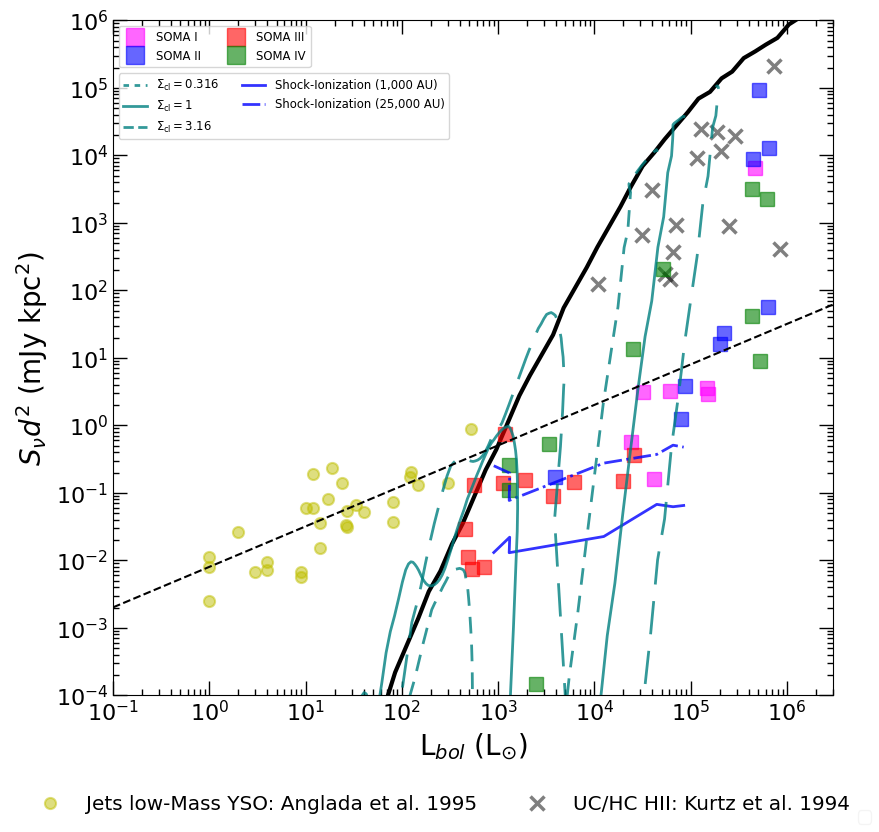

In [5]:
# Setting the plots information
pl.figure(9, figsize=(9,9))
Fig9='Anglada_plot'
fig9=pl.gcf()
ax9 = fig9.add_axes([.15,.15, .8, .75])

custom_handles = []
custom_labels = []

### Thompson 1984 Data ---> For SOMA II and III we use Cesaroni data
#pl.loglog(10**np.array(logL_Th), rad_lum_Th,'-k', linewidth=3,label='_nolegend_',alpha=0.8)

### Cesaroni 1995 Data
rad_lum_cesaroni_data =  2.08e-46 * 10**(np.array(logNe_95_cl))* nu**-0.1 * T_e**0.45 
pl.loglog(10**pl.array(logL_bol_cl), rad_lum_cesaroni_data, 'k-', linewidth=3)

scale= 1.36 # Scaling Anglada95 and slide talks data from 3.6 cm to 6 cm, assuming alpha=0.6
for source in Lit_sources:
    if  data_dict_Lit[source]['Refs'] == 'Anglada_95' and data_dict_Lit[source]['Lum_bol'] != 'na':
        
        Ang_95 = pl.loglog(float(data_dict_Lit[source]['Lum_bol']), float(data_dict_Lit[source]['Radio_lum'])/scale,'.y', 
                           markersize=16, markeredgewidth=1.5,alpha=0.5)           

    scale_k = 0.95  ## asumming an ~flat spectrum -0.1

## HII sources from Kurtz et al. 1994
## These sources are at 3.6 cm, so I need to scale them to 6 cm
    Unresolved_Kurtz_94= ['G10.841-2.592', 'G28.200-0.049', 'G48.61+0.02', 'G76.383-0.621', 'G138.295+1.555', 
                          'G189.030+0.784', 'G189.876+0.516', 'G206.543-16.347']

    if  data_dict_Lit[ source ]['Refs'] == 'Kurtz_94':
        if source not in Unresolved_Kurtz_94:
            Kur_94 = pl.loglog(float(data_dict_Lit[ source ]['Lum_bol']), float(data_dict_Lit[ source ]['Rad_Lum_calc'])/scale_k,'xk', 
                               markersize=10, markeredgewidth=2.5,alpha=0.5)# Kurtz's HII regions

# SOMA Sources
SOMA_I = pl.loglog(lbol_S1, Radio_flux_S1*Dist_S1**2, 's', color='magenta', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA I')
custom_handles.append(Line2D([], [], marker='s', color='magenta', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA I')

SOMA_II = pl.loglog(lbol_S2, Radio_flux_S2*Dist_S2**2, 's', color='blue', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA II')
custom_handles.append(Line2D([], [], marker='s', color='blue', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA II')

SOMA_III = pl.loglog(lbol_S3, Radio_flux_S3*Dist_S3**2, 's', color='red', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA III')
custom_handles.append(Line2D([], [], marker='s', color='red', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA III')

SOMA_IV = pl.loglog(lbol_S4, Radio_flux_S4*Dist_S4**2, 's', color='green', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA IV')
custom_handles.append(Line2D([], [], marker='s', color='green', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA IV')

### This section is to display the sources one by one in the label, as displayed in the Papers
'''
for i, source in enumerate(t_SOMA_I['Region']):  
    label = source.replace('-','$-$').replace('+','$+$').replace('_',' ')
    custom_handles.append(Line2D([], [], marker='s', color=new_colors[i], linestyle='None', markeredgewidth=1.5, alpha=0.6, markersize=13))
    custom_labels.append(label)
    
    pl.loglog(lbol_S1[i], Radio_flux_S1[i]*Dist_S1[i]**2,'s', color=new_colors[i], markersize=13, markeredgewidth=1.5, alpha=0.6)
    
    pl.errorbar(lbol_S1[i], Radio_flux_S1[i]*Dist_S1[i]**2, xerr=[[lbol_S1[i]-lbol_min_S1[i]],[lbol_max_S1[i]+lbol_S1[i]]], 
                ecolor=new_colors[i], elinewidth=2, capsize=7, capthick=3, alpha=0.6)

for i, source in enumerate(t_SOMA_II['Region']):  
    if source == 'IRAS16562-3959_N':    
        circle = Line2D([], [], marker='o', markerfacecolor='none', color=new_colors[i+8], linestyle='None', markersize=13, markeredgewidth=1.5)
        arrow = Line2D([], [], marker=r'$\mathbf{\downarrow}$', color=new_colors[i+8], linestyle='None', markersize=13, markeredgewidth=1.5)
        custom_handles.append((circle, arrow))
        custom_labels.append('IRAS 16562$-$3959 N')

        pl.loglog(lbol_S2[i], Radio_flux_S2[i]*Dist_S2[i]**2, marker='o', markerfacecolor='none', color=new_colors[i+8], markersize=13, markeredgewidth=1.5)
        pl.loglog(lbol_S2[i], Radio_flux_S2[i]*Dist_S2[i]**2, marker=r'$\downarrow$', color=new_colors[i+8], markersize=20, markeredgewidth=1.5)
        
    else:
        if source == 'G305.20+0.21':
            label = 'G305.20+0.21 (G305B)'
        elif source == 'G305.20+0.21A':
            label = 'G305.21+0.21 (G305A)'
        elif source == 'IRAS_16562':
            label = 'IRAS 16562$-$3959'
        else:
            label = source.replace('-','$-$').replace('+','$+$').replace('_',' ')

        custom_handles.append(Line2D([], [], marker='o', color=new_colors[i+8], linestyle='None', markeredgewidth=1.5, alpha=0.6, markersize=13))
        custom_labels.append(label)

        pl.loglog(lbol_S2[i], Radio_flux_S2[i]*Dist_S2[i]**2,'o', color=new_colors[i+8], markersize=13, markeredgewidth=1.5, alpha=0.6)
        
        pl.errorbar(lbol_S2[i], Radio_flux_S2[i]*Dist_S2[i]**2, xerr=[[lbol_S2[i]-lbol_min_S2[i]],[lbol_max_S2[i]+lbol_S2[i]]], 
                    ecolor=new_colors[i+8], elinewidth=2, capsize=7, capthick=3, alpha=0.6)
     
for i, source in enumerate(t_SOMA_III['Region']):  
    if source in ['IRAS_22172+5549_MIR1', 'IRAS_22172+5549_MIR2', 'IRAS_22172+5549_MIR3', 'IRAS_21391+5802_MIR48']:    
        label = source.replace('-','$-$').replace('+','$+$').replace('_',' ')
        circle = Line2D([], [], marker='o', markerfacecolor='none', color=new_colors[i], linestyle='None', markersize=13, markeredgewidth=1.5)
        arrow = Line2D([], [], marker=r'$\mathbf{\downarrow}$', color=new_colors[i], linestyle='None', markersize=13, markeredgewidth=1.5)
        custom_handles.append((circle, arrow))
        custom_labels.append(label)
 
        pl.loglog(lbol_S3[i], Radio_flux_S3[i]*Dist_S3[i]**2, marker='o', markerfacecolor='none', color=new_colors[i], markersize=13, markeredgewidth=1.5)
        pl.loglog(lbol_S3[i], Radio_flux_S3[i]*Dist_S3[i]**2, marker=r'$\downarrow$', color=new_colors[i], markersize=20, markeredgewidth=1.5)
        
    else:
        label = source.replace('-','$-$').replace('+','$+$').replace('_',' ')

        custom_handles.append(Line2D([], [], marker='o', color=new_colors[i], linestyle='None', markeredgewidth=1.5, alpha=0.6, markersize=13))
        custom_labels.append(label)

        pl.loglog(lbol_S3[i], Radio_flux_S3[i]*Dist_S3[i]**2,'o', color=new_colors[i], markersize=13, markeredgewidth=1.5, alpha=0.6)
        
        pl.errorbar(lbol_S3[i], Radio_flux_S3[i]*Dist_S3[i]**2, xerr=[[np.abs(lbol_S3[i]-lbol_min_S3[i])],[np.abs(lbol_max_S3[i]+lbol_S3[i])]], 
                    ecolor=new_colors[i], elinewidth=2, capsize=7, capthick=3, alpha=0.6)
'''

pl.legend(loc=2, numpoints=1, prop=FontProperties(size='x-large'), ncol=2)
pl.legend(handles=custom_handles, labels=custom_labels, loc=2, numpoints=1, prop=FontProperties(size='x-large'), ncol=2)
legend1 = ax9.legend(handles=custom_handles, labels=custom_labels, loc='upper left', numpoints=1, prop=FontProperties(size='small'), handler_map={tuple: HandlerOverlay()}, ncol=2)
ax9.add_artist(legend1)
     
### Emiko's 2024 data
Lbol_emiko = np.array([899.98, 1317.53, 1301.15, 12499.0, 44323.6, 65461.5, 84459.8])
Sv_1000au = np.array([-1.884, -1.657, -1.887, -1.647, -1.171, -1.206, -1.187])
Sv_1000au = 10**Sv_1000au
Sv_25000au = np.array([-0.599, -0.707, -1.113, -0.560, -0.431, -0.294, -0.323])
Sv_25000au = 10**Sv_25000au

au_val = 25000 * u.au
kpc_val = au_val.to(u.kpc)**2

pl.loglog(Lbol_emiko, Sv_1000au, linestyle='-', color='blue', linewidth=2, alpha=0.8)
pl.loglog(Lbol_emiko, Sv_25000au, linestyle='-.', color='blue', linewidth=2, alpha=0.8)

### Tanaka's 2016 data
infile_M601 = 'Data/Anglada Models/stel_Mc60.Sigma1.dat'
M_star_M601, r_star_M601, L_star_M601, T_star_M601, rad_lum_star_M601, Q_star_M601 = np.loadtxt(infile_M601, unpack=True ,usecols=[0, 1, 2, 3, 4, 5])

infile_M602 = 'Data/Anglada Models/stel_Mc60.Sigma3.dat'
M_star_M602, r_star_M602, L_star_M602, T_star_M602, rad_lum_star_M602, Q_star_M602 = np.loadtxt(infile_M602, unpack=True ,usecols=[0, 1, 2, 3, 4, 5])

infile_M603 = 'Data/Anglada Models/stel_Mc60.Sigma0.3.dat'
M_star_M603, r_star_M603, L_star_M603, T_star_M603, rad_lum_star_M603, Q_star_M603 = np.loadtxt(infile_M603, unpack=True ,usecols=[0, 1, 2, 3, 4, 5])

pl.loglog(L_star_M603, np.multiply(rad_lum_star_M603,1.07789612350129e-44),  linestyle=(0, (6, 4)), color= 'teal', linewidth=2, alpha=0.8)
pl.loglog(L_star_M601, np.multiply(rad_lum_star_M601,1.07789612350129e-44), '-', color= 'teal', linewidth=2, alpha=0.8)
pl.loglog(L_star_M602, np.multiply(rad_lum_star_M602,1.07789612350129e-44), linestyle=(0, (12, 6)), color= 'teal', linewidth=2, alpha=0.8)

leg = fig9.legend([Ang_95, Kur_94], ['Jets low-Mass YSO: Anglada et al. 1995', 'UC/HC HII: Kurtz et al. 1994'], loc='lower right', prop=FontProperties(size='large'), numpoints=1)
leg.get_frame().set_alpha(0.2)

short_dash = Line2D([], [], linestyle='-', color='teal', linewidth=2, alpha=0.8, label=r"$\Sigma_{\mathrm{cl}} = 0.316$")
short_dash.set_dashes([2, 2])

legend_handles = [Line2D([], [], linestyle='None', marker='.', color='y', markersize=16, alpha=0.5, markeredgewidth=1.5, label='Jets low-Mass YSO: Anglada et al. 1995'), 
                  Line2D([], [], linestyle='None', marker='x', color='k', markersize=10, alpha=0.5, markeredgewidth=2.5, label='UC/HC HII: Kurtz et al. 1994')]

pl.subplots_adjust(bottom=0.25)
pl.figlegend(handles=legend_handles, loc='lower center', ncol=2, prop=FontProperties(size='x-large'), frameon=False)

legend_handles = [short_dash, Line2D([], [], linestyle='-', color='teal', linewidth=2, alpha=0.8, label=r"$\Sigma_{\mathrm{cl}} = 1$"),
                  Line2D([], [], linestyle='--', color='teal', linewidth=2, alpha=0.8, label=r"$\Sigma_{\mathrm{cl}} = 3.16$"), 
                  Line2D([], [], linestyle='-', color='blue', linewidth=2, alpha=0.8, label=r"Shock-Ionization (1,000 AU)"),
                  Line2D([], [], linestyle='-.', color='blue', linewidth=2, alpha=0.8, label=r"Shock-Ionization (25,000 AU)")]

pl.legend(handles=legend_handles, loc=2, ncol=2, prop=FontProperties(size='medium'))
legend2 = ax9.legend(handles=legend_handles,loc='upper left',bbox_to_anchor=(0, 0.93),numpoints=1,prop=FontProperties(size='small'),ncol=2)

pl.ylabel(r'$S_{\nu}d^{2}$ (mJy kpc$^{2}$)', fontsize='20')
pl.xlabel(r'L$_{bol}$ (L$_{\odot}$)', fontsize='20')

pl.gca().set_ylim(1e-4,1.0e6)
pl.gca().set_xlim(1e-1,3e6)

pl.gca().tick_params(axis='both', reset=True, length=10, width=1, which='major', direction='in')
pl.gca().tick_params(axis='both', reset=True, length=4, width=1, which='minor', direction='in')

## Theretical fit from the low mass sources
plot_lum_v2= pl.array(pl.gcf().gca().get_xlim())
rad_lum_an_v2 = 8*10**(-3)*plot_lum_v2**(0.6)

pl.loglog(plot_lum_v2, rad_lum_an_v2,'--k')
pl.tick_params(labelsize='16')

#path= 'Paper_and_presentation/'
#pl.savefig(path+'Radio_luminosity_inner_lbol.png')
#pl.savefig(path+'Radio_luminosity_inner_lbol.pdf')
pl.show()
pl.close()

### Anglada Plot with protostellar evolutionary track (Yichen Models)

Sigma = 0.1

/var/folders/cx/ltcvfstn1lz3r148g5xgn3880000gn/T/ipykernel_75109/3261259773.py:75: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  leg = fig9.legend([Ang_95, Kur_94], ['Jets low-Mass YSO: Anglada et al. 1995', 'UC/HC HII: Kurtz et al. 1994'], loc='lower right', prop=FontProperties(size='large'), numpoints=1)


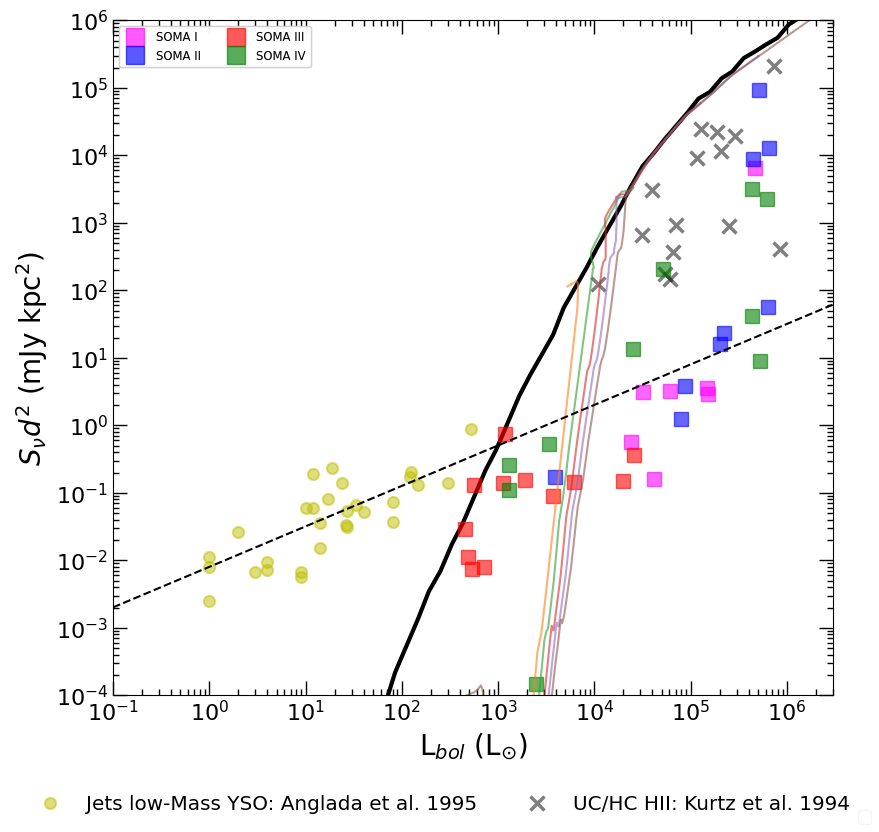

In [6]:
# Setting the plots information
pl.figure(9, figsize=(9,9))
Fig9='Anglada_plot'
fig9=pl.gcf()
ax9 = fig9.add_axes([.15,.15, .8, .75])

custom_handles = []
custom_labels = []

### Thompson 1984 Data ---> For SOMA II and III we use Cesaroni data
#pl.loglog(10**np.array(logL_Th), rad_lum_Th,'-k', linewidth=3,label='_nolegend_',alpha=0.8)

### Cesaroni 1995 Data
rad_lum_cesaroni_data =  2.08e-46 * 10**(np.array(logNe_95_cl))* nu**-0.1 * T_e**0.45 
pl.loglog(10**pl.array(logL_bol_cl), rad_lum_cesaroni_data, 'k-', linewidth=3)

scale= 1.36 # Scaling Anglada95 and slide talks data from 3.6 cm to 6 cm, assuming alpha=0.6
for source in Lit_sources:
    if  data_dict_Lit[source]['Refs'] == 'Anglada_95' and data_dict_Lit[source]['Lum_bol'] != 'na':
        
        Ang_95 = pl.loglog(float(data_dict_Lit[source]['Lum_bol']), float(data_dict_Lit[source]['Radio_lum'])/scale,'.y', 
                           markersize=16, markeredgewidth=1.5,alpha=0.5)           

    scale_k = 0.95  ## asumming an ~flat spectrum -0.1

## HII sources from Kurtz et al. 1994
## These sources are at 3.6 cm, so I need to scale them to 6 cm
    Unresolved_Kurtz_94= ['G10.841-2.592', 'G28.200-0.049', 'G48.61+0.02', 'G76.383-0.621', 'G138.295+1.555', 
                          'G189.030+0.784', 'G189.876+0.516', 'G206.543-16.347']

    if  data_dict_Lit[ source ]['Refs'] == 'Kurtz_94':
        if source not in Unresolved_Kurtz_94:
            Kur_94 = pl.loglog(float(data_dict_Lit[ source ]['Lum_bol']), float(data_dict_Lit[ source ]['Rad_Lum_calc'])/scale_k,'xk', 
                               markersize=10, markeredgewidth=2.5,alpha=0.5)# Kurtz's HII regions

# SOMA Sources
SOMA_I = pl.loglog(lbol_S1, Radio_flux_S1*Dist_S1**2, 's', color='magenta', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA I')
custom_handles.append(Line2D([], [], marker='s', color='magenta', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA I')

SOMA_II = pl.loglog(lbol_S2, Radio_flux_S2*Dist_S2**2, 's', color='blue', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA II')
custom_handles.append(Line2D([], [], marker='s', color='blue', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA II')

SOMA_III = pl.loglog(lbol_S3, Radio_flux_S3*Dist_S3**2, 's', color='red', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA III')
custom_handles.append(Line2D([], [], marker='s', color='red', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA III')

SOMA_IV = pl.loglog(lbol_S4, Radio_flux_S4*Dist_S4**2, 's', color='green', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA IV')
custom_handles.append(Line2D([], [], marker='s', color='green', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA IV')

# Yichen's models
path_all_models = 'Tables/Iradio'
sigma = ['0.1', '1', '3.16']
mcores = ['10', '30', '60', '120', '240', '480']

# Sigma 0.1
for mcore in mcores:
    filename = f'lradio_mcore{mcore}.sigma{sigma[0]}.csv'
    file_path = os.path.normpath(os.path.join(path_all_models, filename))

    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep=r'\s+')
        df.columns = df.columns.str.strip()

        pl.plot(10**df['log(lbol)'], 10**df['log(lradio)'], label=fr"$M_\mathrm{{core}} = {mcore}$", alpha=0.6)

pl.legend(loc=2, numpoints=1, prop=FontProperties(size='x-large'), ncol=2)

pl.legend(handles=custom_handles, labels=custom_labels, loc=2, numpoints=1, prop=FontProperties(size='x-large'), ncol=2)
legend1 = ax9.legend(handles=custom_handles, labels=custom_labels, loc='upper left', numpoints=1, prop=FontProperties(size='small'), handler_map={tuple: HandlerOverlay()}, ncol=2)
ax9.add_artist(legend1)

leg = fig9.legend([Ang_95, Kur_94], ['Jets low-Mass YSO: Anglada et al. 1995', 'UC/HC HII: Kurtz et al. 1994'], loc='lower right', prop=FontProperties(size='large'), numpoints=1)
leg.get_frame().set_alpha(0.2)

legend_handles = [Line2D([], [], linestyle='None', marker='.', color='y', markersize=16, alpha=0.5, markeredgewidth=1.5, label='Jets low-Mass YSO: Anglada et al. 1995'), 
                  Line2D([], [], linestyle='None', marker='x', color='k', markersize=10, alpha=0.5, markeredgewidth=2.5, label='UC/HC HII: Kurtz et al. 1994')]

pl.subplots_adjust(bottom=0.25)
pl.figlegend(handles=legend_handles, loc='lower center', ncol=2, prop=FontProperties(size='x-large'), frameon=False)

pl.ylabel(r'$S_{\nu}d^{2}$ (mJy kpc$^{2}$)', fontsize='20')
pl.xlabel(r'L$_{bol}$ (L$_{\odot}$)', fontsize='20')

pl.gca().set_ylim(1e-4,1.0e6)
pl.gca().set_xlim(1e-1,3e6)

pl.gca().tick_params(axis='both', reset=True, length=10, width=1, which='major', direction='in')
pl.gca().tick_params(axis='both', reset=True, length=4, width=1, which='minor', direction='in')

## Theretical fit from the low mass sources
plot_lum_v2= pl.array(pl.gcf().gca().get_xlim())
rad_lum_an_v2 = 8*10**(-3)*plot_lum_v2**(0.6)

pl.loglog(plot_lum_v2, rad_lum_an_v2,'--k')
pl.tick_params(labelsize='16')

#path = 'Paper_and_presentation/'
#pl.savefig(path+'Radio_luminosity_0.316.png')
#pl.savefig(path+'Radio_luminosity_0.316.pdf')
pl.show()
pl.close()

Sigma = 1

/var/folders/cx/ltcvfstn1lz3r148g5xgn3880000gn/T/ipykernel_75109/1234134915.py:75: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  leg = fig9.legend([Ang_95, Kur_94], ['Jets low-Mass YSO: Anglada et al. 1995', 'UC/HC HII: Kurtz et al. 1994'], loc='lower right', prop=FontProperties(size='large'), numpoints=1)


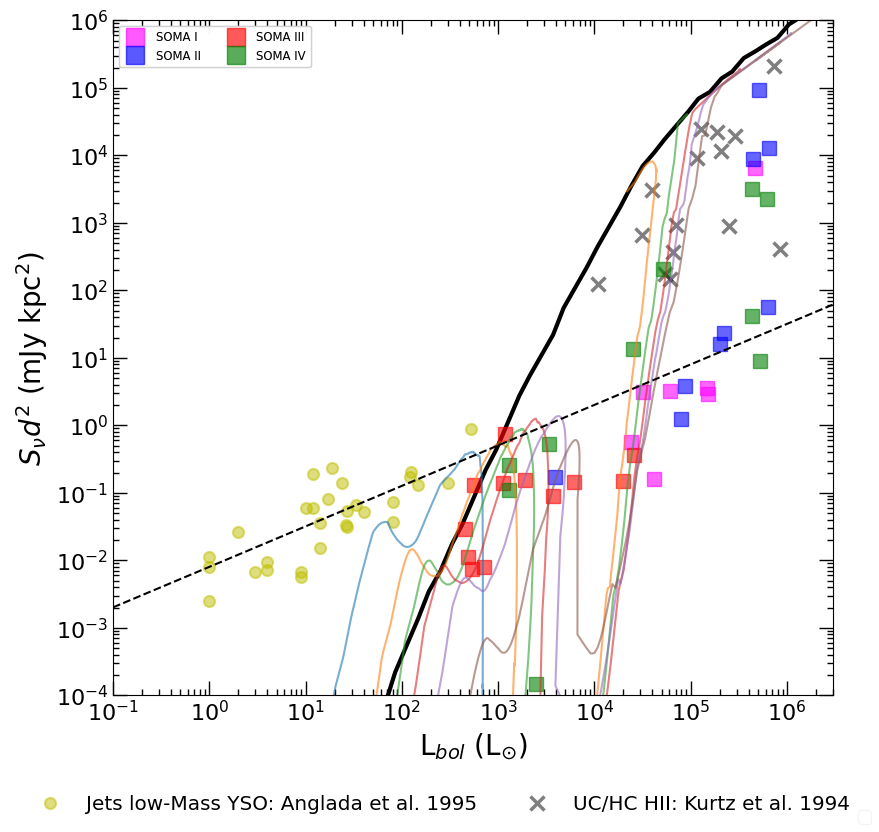

In [7]:
# Setting the plots information
pl.figure(9, figsize=(9,9))
Fig9='Anglada_plot'
fig9=pl.gcf()
ax9 = fig9.add_axes([.15,.15, .8, .75])

custom_handles = []
custom_labels = []

### Thompson 1984 Data ---> For SOMA II and III we use Cesaroni data
#pl.loglog(10**np.array(logL_Th), rad_lum_Th,'-k', linewidth=3,label='_nolegend_',alpha=0.8)

### Cesaroni 1995 Data
rad_lum_cesaroni_data =  2.08e-46 * 10**(np.array(logNe_95_cl))* nu**-0.1 * T_e**0.45 
pl.loglog(10**pl.array(logL_bol_cl), rad_lum_cesaroni_data, 'k-', linewidth=3)

scale= 1.36 # Scaling Anglada95 and slide talks data from 3.6 cm to 6 cm, assuming alpha=0.6
for source in Lit_sources:
    if  data_dict_Lit[source]['Refs'] == 'Anglada_95' and data_dict_Lit[source]['Lum_bol'] != 'na':
        
        Ang_95 = pl.loglog(float(data_dict_Lit[source]['Lum_bol']), float(data_dict_Lit[source]['Radio_lum'])/scale,'.y', 
                           markersize=16, markeredgewidth=1.5,alpha=0.5)           

    scale_k = 0.95  ## asumming an ~flat spectrum -0.1

## HII sources from Kurtz et al. 1994
## These sources are at 3.6 cm, so I need to scale them to 6 cm
    Unresolved_Kurtz_94= ['G10.841-2.592', 'G28.200-0.049', 'G48.61+0.02', 'G76.383-0.621', 'G138.295+1.555', 
                          'G189.030+0.784', 'G189.876+0.516', 'G206.543-16.347']

    if  data_dict_Lit[ source ]['Refs'] == 'Kurtz_94':
        if source not in Unresolved_Kurtz_94:
            Kur_94 = pl.loglog(float(data_dict_Lit[ source ]['Lum_bol']), float(data_dict_Lit[ source ]['Rad_Lum_calc'])/scale_k,'xk', 
                               markersize=10, markeredgewidth=2.5,alpha=0.5)# Kurtz's HII regions

# SOMA Sources
SOMA_I = pl.loglog(lbol_S1, Radio_flux_S1*Dist_S1**2, 's', color='magenta', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA I')
custom_handles.append(Line2D([], [], marker='s', color='magenta', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA I')

SOMA_II = pl.loglog(lbol_S2, Radio_flux_S2*Dist_S2**2, 's', color='blue', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA II')
custom_handles.append(Line2D([], [], marker='s', color='blue', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA II')

SOMA_III = pl.loglog(lbol_S3, Radio_flux_S3*Dist_S3**2, 's', color='red', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA III')
custom_handles.append(Line2D([], [], marker='s', color='red', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA III')

SOMA_IV = pl.loglog(lbol_S4, Radio_flux_S4*Dist_S4**2, 's', color='green', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA IV')
custom_handles.append(Line2D([], [], marker='s', color='green', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA IV')

# Yichen's models
path_all_models = 'Tables_All_SOMA_Sample/Iradio'
sigma = ['0.1', '1', '3.16']
mcores = ['10', '30', '60', '120', '240', '480']

# Sigma 0.1
for mcore in mcores:
    filename = f'lradio_mcore{mcore}.sigma{sigma[1]}.csv'
    file_path = os.path.normpath(os.path.join(path_all_models, filename))

    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep=r'\s+')
        df.columns = df.columns.str.strip()

        pl.plot(10**df['log(lbol)'], 10**df['log(lradio)'], label=fr"$M_\mathrm{{core}} = {mcore}$", alpha=0.6)

pl.legend(loc=2, numpoints=1, prop=FontProperties(size='x-large'), ncol=2)

pl.legend(handles=custom_handles, labels=custom_labels, loc=2, numpoints=1, prop=FontProperties(size='x-large'), ncol=2)
legend1 = ax9.legend(handles=custom_handles, labels=custom_labels, loc='upper left', numpoints=1, prop=FontProperties(size='small'), handler_map={tuple: HandlerOverlay()}, ncol=2)
ax9.add_artist(legend1)

leg = fig9.legend([Ang_95, Kur_94], ['Jets low-Mass YSO: Anglada et al. 1995', 'UC/HC HII: Kurtz et al. 1994'], loc='lower right', prop=FontProperties(size='large'), numpoints=1)
leg.get_frame().set_alpha(0.2)

legend_handles = [Line2D([], [], linestyle='None', marker='.', color='y', markersize=16, alpha=0.5, markeredgewidth=1.5, label='Jets low-Mass YSO: Anglada et al. 1995'), 
                  Line2D([], [], linestyle='None', marker='x', color='k', markersize=10, alpha=0.5, markeredgewidth=2.5, label='UC/HC HII: Kurtz et al. 1994')]

pl.subplots_adjust(bottom=0.25)
pl.figlegend(handles=legend_handles, loc='lower center', ncol=2, prop=FontProperties(size='x-large'), frameon=False)

pl.ylabel(r'$S_{\nu}d^{2}$ (mJy kpc$^{2}$)', fontsize='20')
pl.xlabel(r'L$_{bol}$ (L$_{\odot}$)', fontsize='20')

pl.gca().set_ylim(1e-4,1.0e6)
pl.gca().set_xlim(1e-1,3e6)

pl.gca().tick_params(axis='both', reset=True, length=10, width=1, which='major', direction='in')
pl.gca().tick_params(axis='both', reset=True, length=4, width=1, which='minor', direction='in')

## Theretical fit from the low mass sources
plot_lum_v2= pl.array(pl.gcf().gca().get_xlim())
rad_lum_an_v2 = 8*10**(-3)*plot_lum_v2**(0.6)

pl.loglog(plot_lum_v2, rad_lum_an_v2,'--k')
pl.tick_params(labelsize='16')

#path = 'Paper_and_presentation/'
#pl.savefig(path+'Radio_luminosity_0.316.png')
#pl.savefig(path+'Radio_luminosity_0.316.pdf')
pl.show()
pl.close()

Sigma = 3.16

/var/folders/cx/ltcvfstn1lz3r148g5xgn3880000gn/T/ipykernel_75109/3735196627.py:75: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  leg = fig9.legend([Ang_95, Kur_94], ['Jets low-Mass YSO: Anglada et al. 1995', 'UC/HC HII: Kurtz et al. 1994'], loc='lower right', prop=FontProperties(size='large'), numpoints=1)


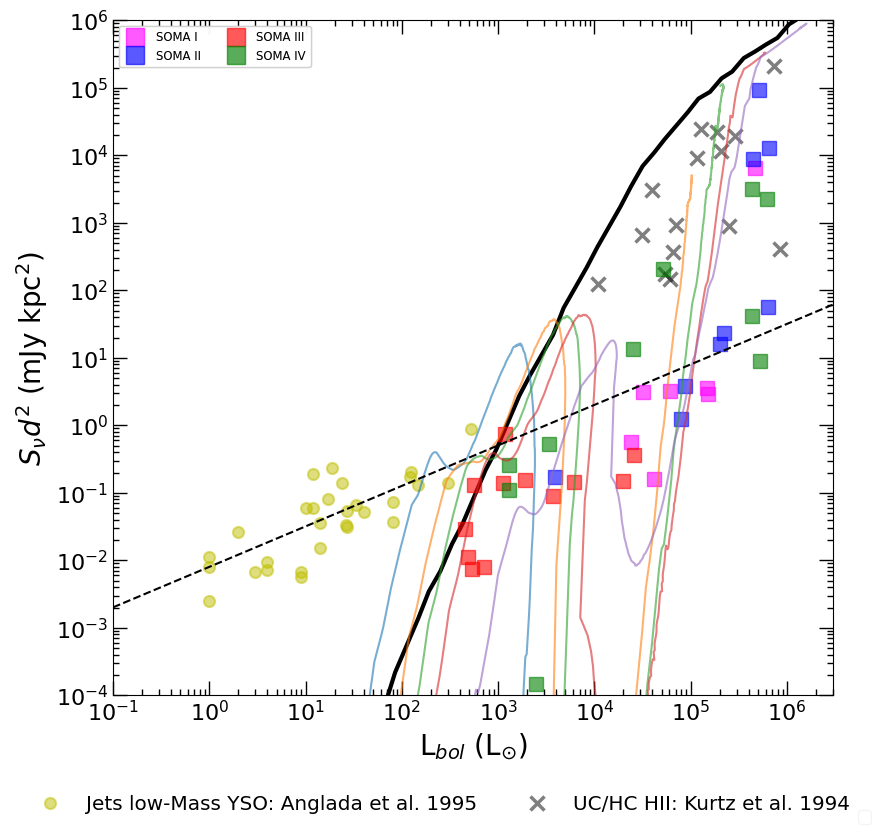

In [8]:
# Setting the plots information
pl.figure(9, figsize=(9,9))
Fig9='Anglada_plot'
fig9=pl.gcf()
ax9 = fig9.add_axes([.15,.15, .8, .75])

custom_handles = []
custom_labels = []

### Thompson 1984 Data ---> For SOMA II and III we use Cesaroni data
#pl.loglog(10**np.array(logL_Th), rad_lum_Th,'-k', linewidth=3,label='_nolegend_',alpha=0.8)

### Cesaroni 1995 Data
rad_lum_cesaroni_data =  2.08e-46 * 10**(np.array(logNe_95_cl))* nu**-0.1 * T_e**0.45 
pl.loglog(10**pl.array(logL_bol_cl), rad_lum_cesaroni_data, 'k-', linewidth=3)

scale= 1.36 # Scaling Anglada95 and slide talks data from 3.6 cm to 6 cm, assuming alpha=0.6
for source in Lit_sources:
    if  data_dict_Lit[source]['Refs'] == 'Anglada_95' and data_dict_Lit[source]['Lum_bol'] != 'na':
        
        Ang_95 = pl.loglog(float(data_dict_Lit[source]['Lum_bol']), float(data_dict_Lit[source]['Radio_lum'])/scale,'.y', 
                           markersize=16, markeredgewidth=1.5,alpha=0.5)           

    scale_k = 0.95  ## asumming an ~flat spectrum -0.1

## HII sources from Kurtz et al. 1994
## These sources are at 3.6 cm, so I need to scale them to 6 cm
    Unresolved_Kurtz_94= ['G10.841-2.592', 'G28.200-0.049', 'G48.61+0.02', 'G76.383-0.621', 'G138.295+1.555', 
                          'G189.030+0.784', 'G189.876+0.516', 'G206.543-16.347']

    if  data_dict_Lit[ source ]['Refs'] == 'Kurtz_94':
        if source not in Unresolved_Kurtz_94:
            Kur_94 = pl.loglog(float(data_dict_Lit[ source ]['Lum_bol']), float(data_dict_Lit[ source ]['Rad_Lum_calc'])/scale_k,'xk', 
                               markersize=10, markeredgewidth=2.5,alpha=0.5)# Kurtz's HII regions

# SOMA Sources
SOMA_I = pl.loglog(lbol_S1, Radio_flux_S1*Dist_S1**2, 's', color='magenta', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA I')
custom_handles.append(Line2D([], [], marker='s', color='magenta', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA I')

SOMA_II = pl.loglog(lbol_S2, Radio_flux_S2*Dist_S2**2, 's', color='blue', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA II')
custom_handles.append(Line2D([], [], marker='s', color='blue', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA II')

SOMA_III = pl.loglog(lbol_S3, Radio_flux_S3*Dist_S3**2, 's', color='red', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA III')
custom_handles.append(Line2D([], [], marker='s', color='red', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA III')

SOMA_IV = pl.loglog(lbol_S4, Radio_flux_S4*Dist_S4**2, 's', color='green', markersize=10, markeredgewidth=1, alpha=0.6, label='SOMA IV')
custom_handles.append(Line2D([], [], marker='s', color='green', linestyle='None', markeredgewidth=1, alpha=0.6, markersize=13))
custom_labels.append('SOMA IV')

# Yichen's models
path_all_models = 'Tables_All_SOMA_Sample/Iradio'
sigma = ['0.1', '1', '3.16']
mcores = ['10', '30', '60', '120', '240', '480']

# Sigma 0.1
for mcore in mcores:
    filename = f'lradio_mcore{mcore}.sigma{sigma[2]}.csv'
    file_path = os.path.normpath(os.path.join(path_all_models, filename))

    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep=r'\s+')
        df.columns = df.columns.str.strip()

        pl.plot(10**df['log(lbol)'], 10**df['log(lradio)'], label=fr"$M_\mathrm{{core}} = {mcore}$", alpha=0.6)

pl.legend(loc=2, numpoints=1, prop=FontProperties(size='x-large'), ncol=2)

pl.legend(handles=custom_handles, labels=custom_labels, loc=2, numpoints=1, prop=FontProperties(size='x-large'), ncol=2)
legend1 = ax9.legend(handles=custom_handles, labels=custom_labels, loc='upper left', numpoints=1, prop=FontProperties(size='small'), handler_map={tuple: HandlerOverlay()}, ncol=2)
ax9.add_artist(legend1)

leg = fig9.legend([Ang_95, Kur_94], ['Jets low-Mass YSO: Anglada et al. 1995', 'UC/HC HII: Kurtz et al. 1994'], loc='lower right', prop=FontProperties(size='large'), numpoints=1)
leg.get_frame().set_alpha(0.2)

legend_handles = [Line2D([], [], linestyle='None', marker='.', color='y', markersize=16, alpha=0.5, markeredgewidth=1.5, label='Jets low-Mass YSO: Anglada et al. 1995'), 
                  Line2D([], [], linestyle='None', marker='x', color='k', markersize=10, alpha=0.5, markeredgewidth=2.5, label='UC/HC HII: Kurtz et al. 1994')]

pl.subplots_adjust(bottom=0.25)
pl.figlegend(handles=legend_handles, loc='lower center', ncol=2, prop=FontProperties(size='x-large'), frameon=False)

pl.ylabel(r'$S_{\nu}d^{2}$ (mJy kpc$^{2}$)', fontsize='20')
pl.xlabel(r'L$_{bol}$ (L$_{\odot}$)', fontsize='20')

pl.gca().set_ylim(1e-4,1.0e6)
pl.gca().set_xlim(1e-1,3e6)

pl.gca().tick_params(axis='both', reset=True, length=10, width=1, which='major', direction='in')
pl.gca().tick_params(axis='both', reset=True, length=4, width=1, which='minor', direction='in')

## Theretical fit from the low mass sources
plot_lum_v2= pl.array(pl.gcf().gca().get_xlim())
rad_lum_an_v2 = 8*10**(-3)*plot_lum_v2**(0.6)

pl.loglog(plot_lum_v2, rad_lum_an_v2,'--k')
pl.tick_params(labelsize='16')

#path = 'Paper_and_presentation/'
#pl.savefig(path+'Radio_luminosity_0.316.png')
#pl.savefig(path+'Radio_luminosity_0.316.pdf')
pl.show()
pl.close()